Name: Leighton Flanagan

Labpartner(s)

In [ ]:
#import statements go here


# Class 12.2

# Warmup 12.2

Kelsey and Asante are going to demo ARC PRO and give you some exercises.

# Lecture 12.2

### Announcements

- Reminder **Reminder all labs through 9.2 need to be completed, or resubmitted if you did not get a satisfactory grade, by end of the day Friday 11/15 to pass the course.** The understanding of this beginning material is needed to complete this course. If you turned it in or resubmitted one and are waiting for me to grade it, no worries. We can get them all finalized next week. 
  
- We are going to do an advanced lab today. For those of you struggling to catch up, you can not worry about this one and focus on previous labs. See syllabus for grading policy.


### Agenda
- Predator prey modeling. We are going to actually do some scientific modelng today!

## Predator Prey Modeling

See what this lab was based on here: 

https://github.com/numerical-mooc/assignment-bank/blob/master/Lessons.and.Assignments/Predator.Prey.Model/Predator.Prey.Model.ipynb

For a more advanced example in predator prey modeling:

https://waterprogramming.wordpress.com/tag/predator-prey/

Modeling the zombie aplocalypse:

https://scipy-cookbook.readthedocs.io/items/Zombie_Apocalypse_ODEINT.html



###  12.2.1 Lotka-Volterra Equations

The Lotka–Volterra equations, also known as the predator–prey equations, are a pair of first-order, non-linear, differential
equations. They are frequently used to describe the dynamics of biological systems in which two species interact, one as a predator and
the other as prey. You can read more about this from Wikipedia <http://en.wikipedia.org/wiki/Lotka-Volterra_equation>.

#### Equations describing the system

 Their populations change with time according to the following pair of equations:

$ dx/dt = x ( \alpha - \beta y  ) $

$ dy/dt = -y( \gamma - \delta x ) $

Where, $x$ is the number of prey (e.g., phytoplankton), $y$ is the number of predators (e.g., zooplankton). $dx/dt, dy/dt$ gives the rate of change of their respective populations over 
time $t$. $\alpha, \beta, \gamma, \delta $ are the parameters describing the interaction between the two species. This models makes some assumptions about 
the predator and prey. You can read about them from the Wikipedia page mentioned above.

The above equations can be written in a slightly different form to interpret the physical meaning of the four parameters used.

1.Rate equation for prey

$dx/dt = \alpha x - \beta x y $

The prey population (x) is presumed to have unlimited supply of food, $\alpha x$ represents the rate of population growth of prey. Rate of decrease of population of prey is assumed to be proportional to the rate at which predator and prey encounter each other, given by $ \beta y x$

2.Rate equation for predator

$ dy/dt = \delta x y -\gamma y $

For the predator population (y), $\delta x y $ gives the rate of growth of predator population. Note that this is similar to the rate of decrease of population of prey. The second term $\gamma y $ gives the rate of population decrease for predators due to natural death or emigration.

### 12.2.2 Numerical solution using Python

A simple python code for solving these equations is shown below.

In [1]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set the parameters
alpha = 1.
beta = 1.2
gamma = 4.
delta = 1.

In [3]:
#define the time stepping scheme - Euler forward or "shooting" method

def euler_step(u, f, dt):
    """Returns the solution at the next time-step using Euler's method.
    
    Parameters
    ----------
    u : array of float
        solution at the previous time-step.
    f : function
        function to compute the right hand-side of the system of equation.
    dt : float
        time-increment.
    
    Returns
    -------
    u_n_plus_1 : array of float
        approximate solution at the next time step.
    """
    
    return u + dt * f(u)

In [4]:
# define the function that represents the Lotka-Volterra equations
# u is the x,y state of the system, what the population is at a given time.
# u = [x,y] on array with both the predetor and prey variables

def f(u):
    """Returns the rate of change of species
    
    Parameters
    ----------
    u : array of float
        array containing the solution at time n.
        
    Returns
    -------
    dudt : array of float
        array containing the RHS given u.
    """
    x = u[0]
    y = u[1]
    return np.array([x*(alpha - beta*y), -y*(gamma - delta*x)])


In [5]:
# set time-increment and discretize the time
T  = 15.0                           # final time
dt = 0.01                           # set time-increment
N  = int(T/dt) + 1                  # number of time-steps

# initial conditions (initial populations):
x0 = 10. # initial prey amount
y0 = 2. # initial predator amount
t0 = 0.

# initialize the array containing the solution for each time-step
u_euler = np.zeros((N, 2))

# imput initial conditions
u_euler[0] = np.array([x0, y0])


In [6]:
u_euler

array([[10.,  2.],
       [ 0.,  0.],
       [ 0.,  0.],
       ...,
       [ 0.,  0.],
       [ 0.,  0.],
       [ 0.,  0.]])

In [7]:
# use a for loop to call the function euler_step()
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [8]:
u_euler

array([[10.        ,  2.        ],
       [ 9.86      ,  2.12      ],
       [ 9.7077616 ,  2.244232  ],
       ...,
       [ 0.87954346,  0.04493602],
       [ 0.88786462,  0.04353381],
       [ 0.89627944,  0.04217898]])

We will now plot the variation of population for each species with time.

In [9]:
# break up the solutions for plotting
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model')

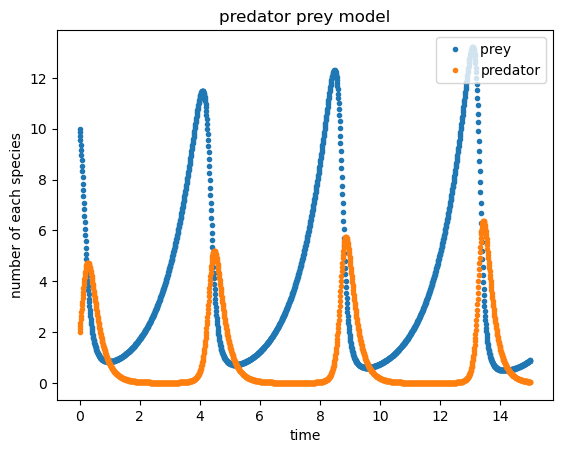

In [10]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Let's think a bit about what this solution means, what is going on here?

There is always more prey than predators. I guess we are assuming a condition of unlimited resources for the prey, which is what allows for their exponential growth. The increase in prey allows for an increase in predators with a slight lag behind the prey increase. Once the predators overwhelm the prey, the prey population drops steeply, triggering a similar pattern in the predator population. This trend cycles about 4 times in 14 units of time.

What happens if we start with different initial conditions? Like more prey and less predators.

In [11]:
x0 = 20
y0 = 1
u_euler[0] = np.array([x0, y0])

In [12]:
# use a for loop to call the function euler_step()
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [13]:
u_euler

array([[20.        ,  1.        ],
       [19.96      ,  1.16      ],
       [19.8817568 ,  1.345136  ],
       ...,
       [ 0.02822124,  2.06726638],
       [ 0.02780336,  1.98515913],
       [ 0.02741907,  1.90630471]])

In [14]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model')

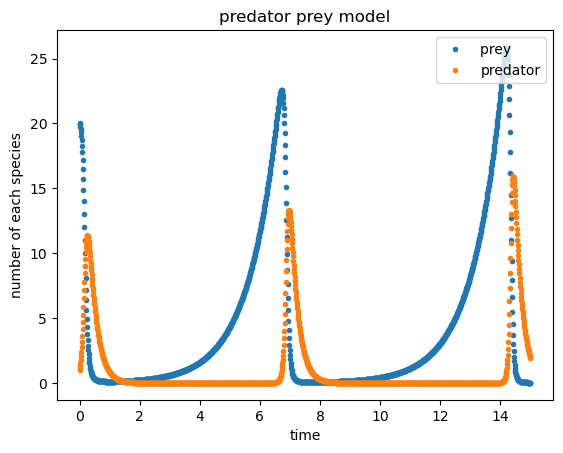

In [15]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

What happened?

The number of prey, and therefore the number of predators, are allowed to increase to about double the amount of the first model. This is coupled with fewer cycles within the given time frame.

What if we start with the same amount of prey and predators?

In [16]:
x0 = 20
y0 = 20
u_euler[0] = np.array([x0, y0])

In [17]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [18]:
u_euler

array([[2.00000000e+01, 2.00000000e+01],
       [1.54000000e+01, 2.32000000e+01],
       [1.12666400e+01, 2.58448000e+01],
       ...,
       [4.35000308e-06, 2.29048124e-01],
       [4.38154679e-06, 2.19886209e-01],
       [4.41380096e-06, 2.11090770e-01]])

In [19]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model')

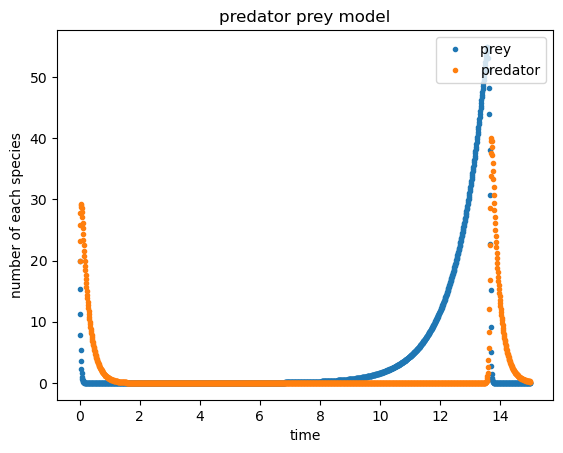

In [20]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

What happened?

Start with a major decrease in predators and prey since 20 prey cannot support 20 predators. Then the cycle starts again. However, if it reaches zero, would the model not prevent the populations from growing again? I know that the model doesn't actually reach zero but you can't have a reproductive .000001th of an organism right?

Let's mess around with the model parameters. What if the prey grow faster?

In [21]:
# set the parameters
alpha = 2.
beta = 1.2
gamma = 4.
delta = 1.

In [22]:
x0 = 10
y0 = 2
u_euler[0] = np.array([x0, y0])

In [23]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [24]:
u_euler

array([[10.        ,  2.        ],
       [ 9.96      ,  2.12      ],
       [ 9.9058176 ,  2.246352  ],
       ...,
       [ 0.25290187,  1.69146926],
       [ 0.2528266 ,  1.62808825],
       [ 0.25294364,  1.56708096]])

In [25]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

What happened?

Because the prey grows faster, you get more oscillations within the time frame.

### 12.2.3 System behavior

A better understanding of the system behavior can be obtained by a phase plot of the population of predators vs. the population of prey. It will tell us if the system sustains or collapses over time. For the choice of parameters $ \alpha, \beta, \gamma $ and $ \delta $ made above, we see that the maximum population of each species keeps increasing each cycle. You can read more about that in the Wikipedia link mentioned above.

Text(0.5, 1.0, 'predator prey model')

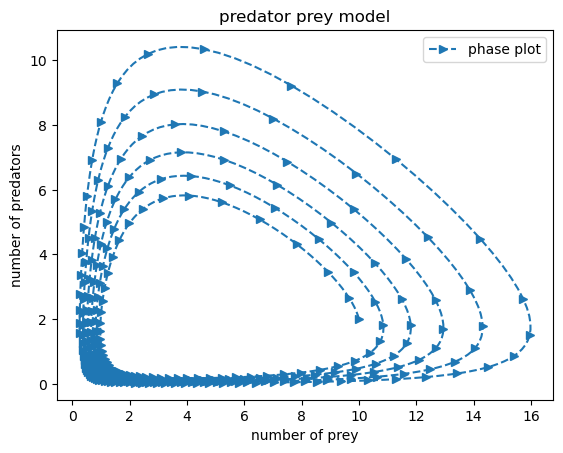

In [26]:
plt.plot(x_euler, y_euler, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

# Lab 12.2

#### E.1 How does timestep affect the solution?
Modify the timestep (or time increment) dt. How does this affect your solutions? Plot both the timeseries and the phase plots. Try making dt 10 times bigger (dt = 0.1) and 10 times smaller. Describe what happens to your results. What happens if you make dt 100 times smaller?

In [27]:
alpha = 1.
beta = 1.2
gamma = 4.
delta = 1.

In [28]:
T  = 15.0
dt = 0.1
N  = int(T/dt) + 1 

In [29]:
u_euler = np.zeros((N, 2))

In [30]:
x0 = 10
y0 = 2
u_euler[0] = np.array([x0, y0])

In [31]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [32]:
u_euler

array([[ 1.00000000e+01,  2.00000000e+00],
       [ 8.60000000e+00,  3.20000000e+00],
       [ 6.15760000e+00,  4.67200000e+00],
       [ 3.32116314e+00,  5.68003072e+00],
       [ 1.38956241e+00,  5.29444930e+00],
       [ 6.45682526e-01,  3.91236635e+00],
       [ 4.07113188e-01,  2.60003447e+00],
       [ 3.20803508e-01,  1.66587151e+00],
       [ 2.88753768e-01,  1.05296465e+00],
       [ 2.81143443e-01,  6.62183542e-01],
       [ 2.86917560e-01,  4.15926981e-01],
       [ 3.01288906e-01,  2.61489864e-01],
       [ 3.21963717e-01,  1.64772318e-01],
       [ 3.47794004e-01,  1.04168462e-01],
       [ 3.78225904e-01,  6.61239936e-02],
       [ 4.13047318e-01,  4.21753769e-02],
       [ 4.52261598e-01,  2.70472687e-02],
       [ 4.96019865e-01,  1.74516053e-02],
       [ 5.44583090e-01,  1.13365975e-02],
       [ 5.98300553e-01,  7.41933043e-03],
       [ 6.57597930e-01,  4.89549721e-03],
       [ 7.22971411e-01,  3.25922521e-03],
       [ 7.94985792e-01,  2.19116779e-03],
       [ 8.

In [33]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model')

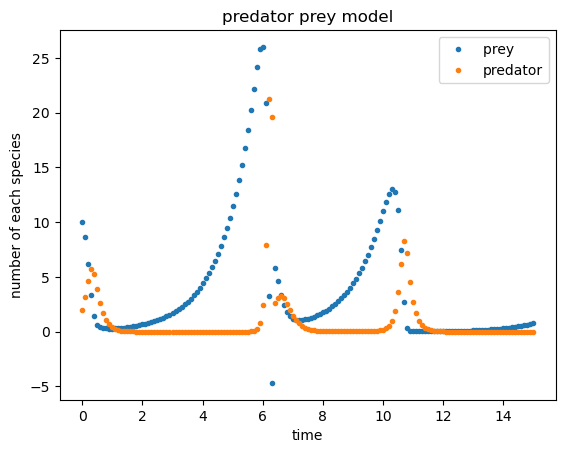

In [34]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

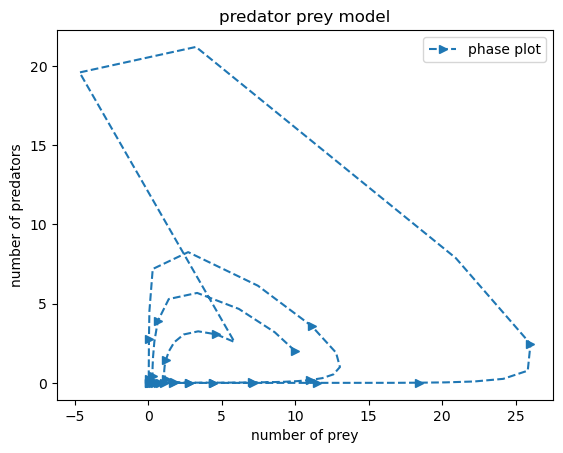

In [35]:
plt.plot(x_euler, y_euler, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

In [36]:
T  = 15.0
dt = 0.001
N  = int(T/dt) + 1 

In [37]:
u_euler = np.zeros((N, 2))

In [38]:
x0 = 10
y0 = 2
u_euler[0] = np.array([x0, y0])

In [39]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [40]:
u_euler

array([[10.        ,  2.        ],
       [ 9.986     ,  2.012     ],
       [ 9.9718758 ,  2.02404383],
       ...,
       [ 3.06426426,  0.0174817 ],
       [ 3.06726424,  0.01746534],
       [ 3.07026722,  0.01744905]])

In [41]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model')

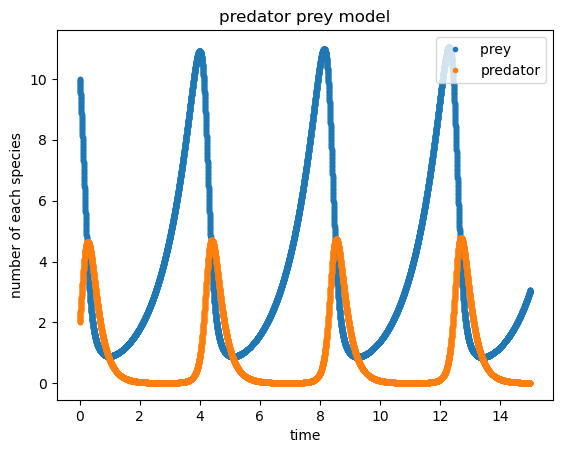

In [42]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

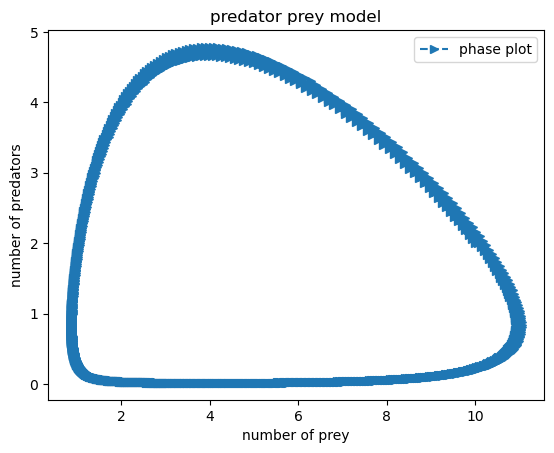

In [43]:
plt.plot(x_euler, y_euler, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

In [44]:
T  = 15.0
dt = 0.0001
N  = int(T/dt) + 1 

In [45]:
u_euler = np.zeros((N, 2))

In [46]:
x0 = 10
y0 = 2
u_euler[0] = np.array([x0, y0])

In [47]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [48]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model')

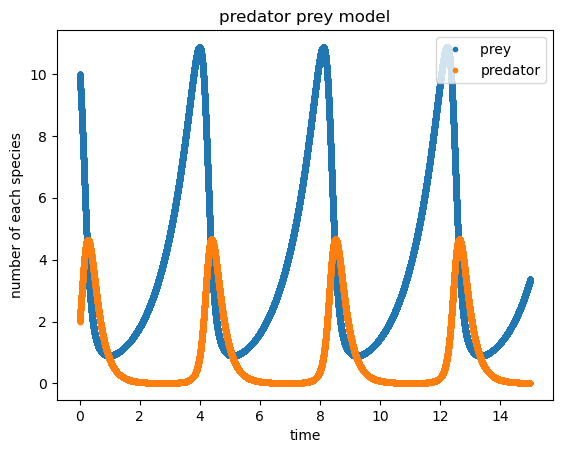

In [49]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

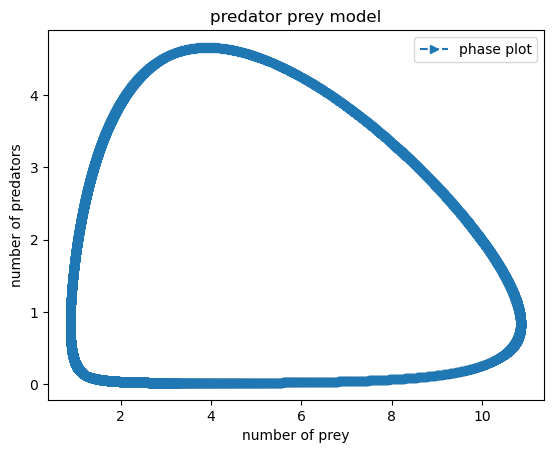

In [299]:
plt.plot(x_euler, y_euler, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

Decreasing the time step increases the resolution of the model. 

#### E.2 Adding the steady state

The steady state(s) of the system are found by setting the population equations to zero, that is the solution to when the population is not changing. This is also called a "fixed point" of the equations, since if the populations start there they stay there, i.e. are fixed.

Find the steady states of the system using algebra. Plot the fixed point (steady state population) of the system on both the timeseries and phase space plots. Describe where the fixed point is in the phase space plot and plot it. What happens if you start at the steady state? What happens if you start near the steady state?

$\alpha x - \beta x y  = 0$

$\delta x y -\gamma y  = 0$



Algebra done by hand, although by looking at others' answers, I may have overcomplicated it

In [184]:
T  = 15.0
dt = 0.01
N  = int(T/dt) + 1 

In [185]:
u_euler = np.zeros((N, 2))

In [211]:
x0 = 10
y0 = 2
u_euler[0] = np.array([x0, y0])

In [212]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [213]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model')

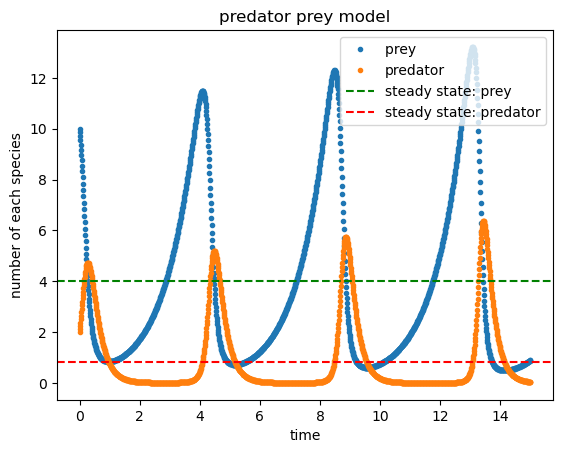

In [214]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.axhline(4, color = 'g', linestyle = '--', label = 'steady state: prey')
plt.axhline(0.8333, color = 'r', linestyle = '--', label = 'steady state: predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

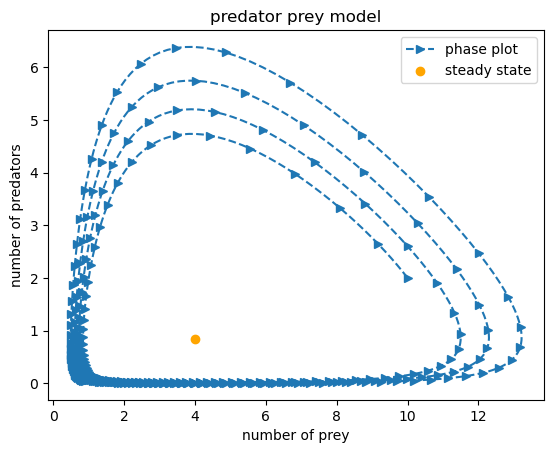

In [215]:
plt.plot(x_euler, y_euler, '-->', markevery=5, label = 'phase plot')
plt.scatter(4, 0.8333, color = 'orange', label = "steady state")
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

In [227]:
x0 = 4
y0 = 0.8333
u_euler[0] = np.array([x0, y0])

In [228]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [229]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model at steady state')

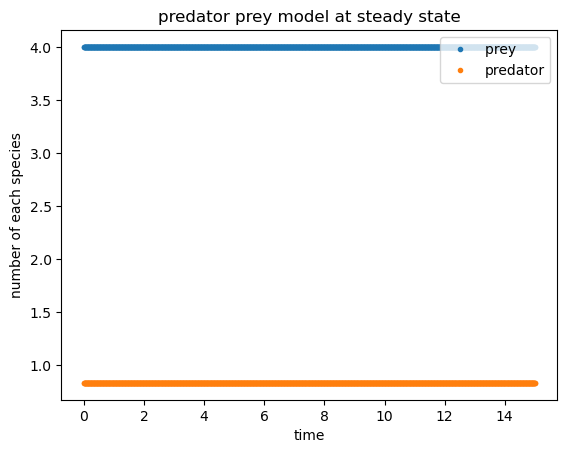

In [230]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model at steady state")

Text(0.5, 1.0, 'predator prey model at steady state')

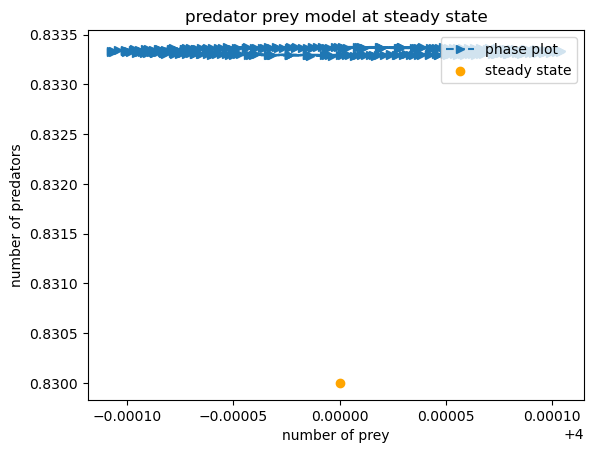

In [231]:
plt.plot(x_euler, y_euler, '-->', markevery=5, label = 'phase plot')
plt.scatter(4, 0.83, color = 'orange', label = "steady state")
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model at steady state")

In [221]:
x0 = 4.2
y0 = 0.9
u_euler[0] = np.array([x0, y0])

In [222]:
for n in range(N-1):
    u_euler[n+1] = euler_step(u_euler[n], f, dt)

In [223]:
time = np.linspace(0.0, T,N)
x_euler = u_euler[:,0]
y_euler = u_euler[:,1]

Text(0.5, 1.0, 'predator prey model close to steady state')

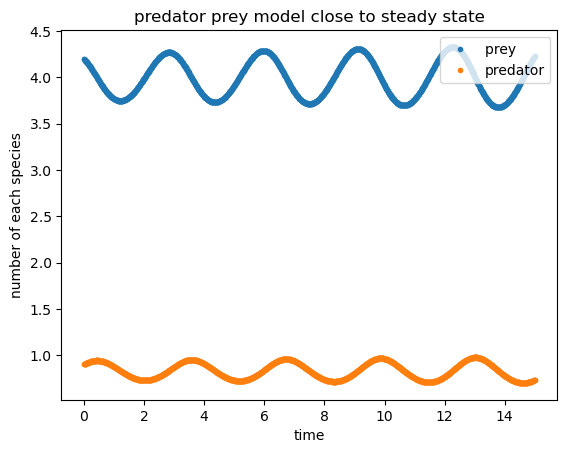

In [225]:
plt.plot(time, x_euler, '.', label = 'prey ')
plt.plot(time, y_euler, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model close to steady state")

Text(0.5, 1.0, 'predator prey model close to steady state')

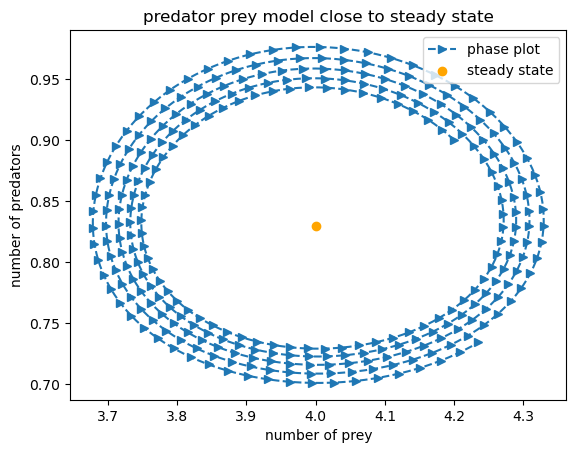

In [226]:
plt.plot(x_euler, y_euler, '-->', markevery=5, label = 'phase plot')
plt.scatter(4, 0.83, color = 'orange', label = "steady state")
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model close to steady state")

#### E.3 A better algorithm
Do Exercise 1 again with a fourth order time stepping method called "Runge-Kutta 4" whose algorithm is given below. Do your answers differ? How does the dt, the timestep, affect your answer using this "higher order" algorithm?

In [50]:
def RK4(u,f,dt):
    # Runge Kutta 4th order method
    """Returns the solution at the next time-step using Runge Kutta fourth order (RK4) method.
    
    Parameters
    ----------
    u : array of float
        solution at the previous time-step.
    f : function
        function to compute the right hand-side of the system of equation.
    dt : float
        time-increment.
    
    Returns
    -------
    u_n_plus_1 : array of float
        approximate solution at the next time step.
    """
    #calculate slopes
    k1 = f(u)
    u1 = u + (dt/2.)*k1
    k2 = f(u1)
    u2 = u + (dt/2.)*k2
    k3 = f(u2)
    u3 = u + dt*k3
    k4 = f(u3)
    return u + (dt/6.)*(k1 + 2.*k2 + 2.*k3 + k4)

In [51]:
T  = 15.0   
dt = 0.01   
N  = int(T/dt) + 1

In [52]:
u_RK4 = np.zeros((N, 2))

In [53]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [54]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [55]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model')

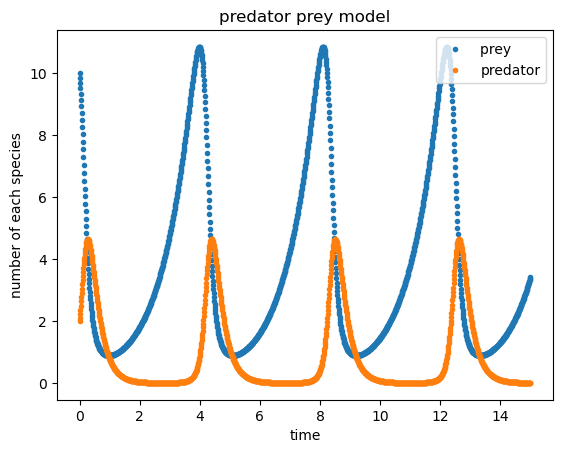

In [56]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

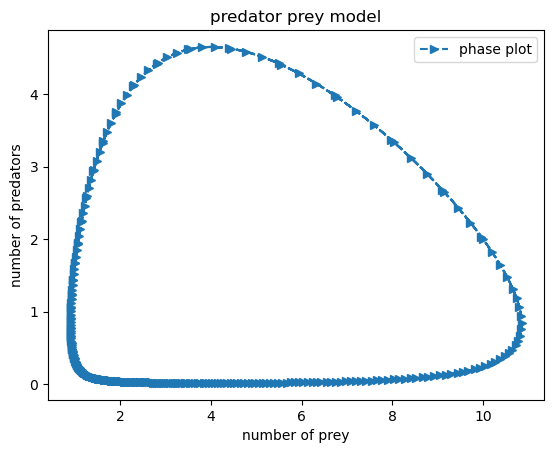

In [57]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

In [58]:
T  = 15.0   
dt = 0.1   
N  = int(T/dt) + 1

In [59]:
u_RK4 = np.zeros((N, 2))

In [60]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [61]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [62]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model')

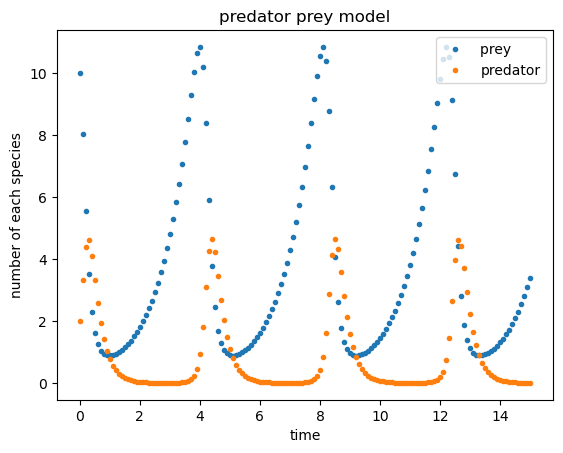

In [63]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

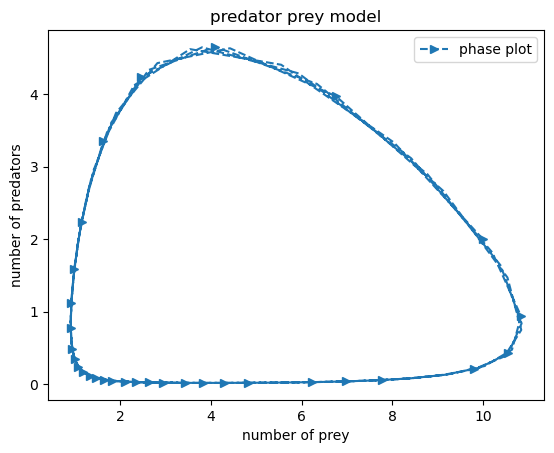

In [64]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

In [65]:
T  = 15.0   
dt = 0.001
N  = int(T/dt) + 1

In [66]:
u_RK4 = np.zeros((N, 2))

In [67]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [68]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [69]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model')

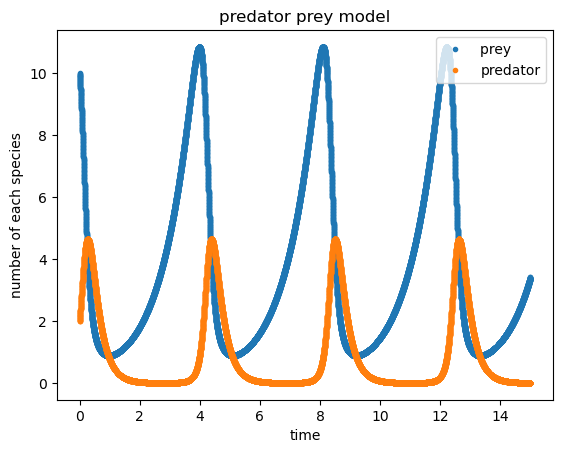

In [70]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

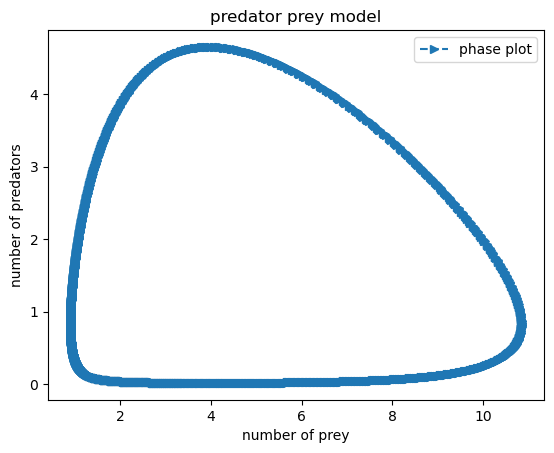

In [71]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

In [72]:
T  = 15.0   
dt = 0.0001
N  = int(T/dt) + 1

In [73]:
u_RK4 = np.zeros((N, 2))

In [74]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [75]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [76]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model')

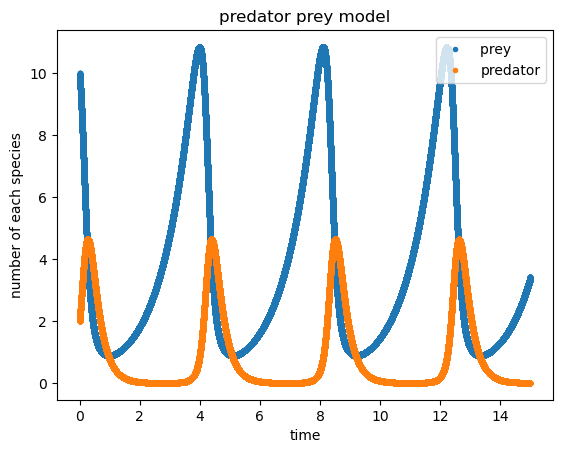

In [77]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model")

Text(0.5, 1.0, 'predator prey model')

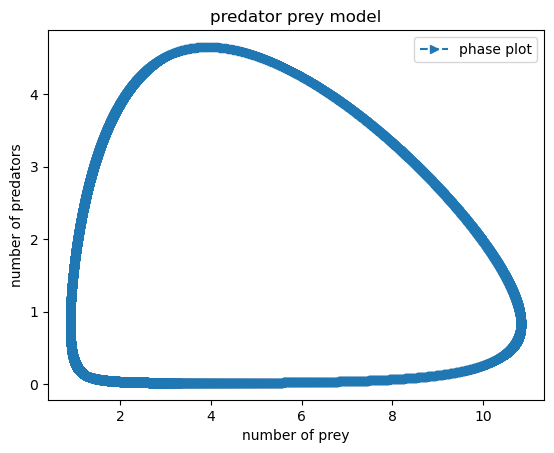

In [78]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("predator prey model")

Adjusting the time step in the RK4 model is so much more sensitive than in the euler model.

#### E.4 Exploring parameter space
Vary the interactions between species by changing $\alpha, \beta, \gamma, \delta$ and see what happens to the population evolution as well as phase plots. How does changing each parameter individually affect the system?

In [99]:
T  = 15.0                           # final time
dt = 0.01                           # set time-increment
N  = int(T/dt) + 1  

In [100]:
u_RK4 = np.zeros((N, 2))

In [101]:
alpha = 10.
beta = 1.2
gamma = 4.
delta = 1.

In [102]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [103]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [104]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model alpha')

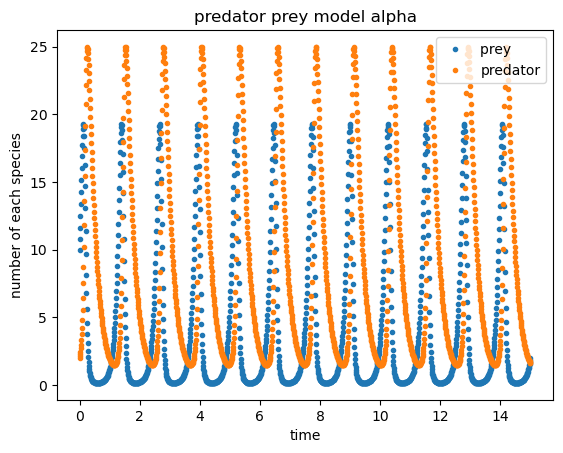

In [105]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model alpha")

Text(0.5, 1.0, 'phase model alpha')

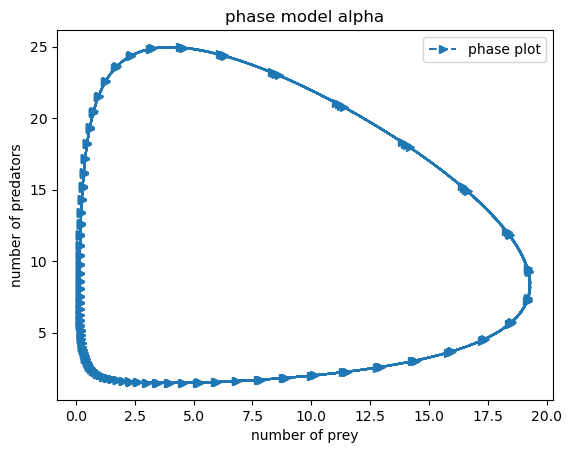

In [106]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("phase model alpha")

Changing alpha means changing the growth rate of the prey (we did this earlier in the lecture). This means that increasing alpha leads to many more cycles within the given time frame.

In [107]:
alpha = 1.
beta = 12
gamma = 4.
delta = 1.

In [108]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [109]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [110]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model beta')

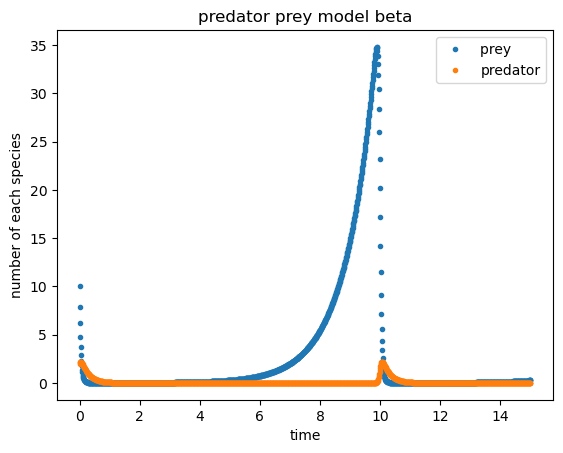

In [111]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model beta")

Text(0.5, 1.0, 'phase model beta')

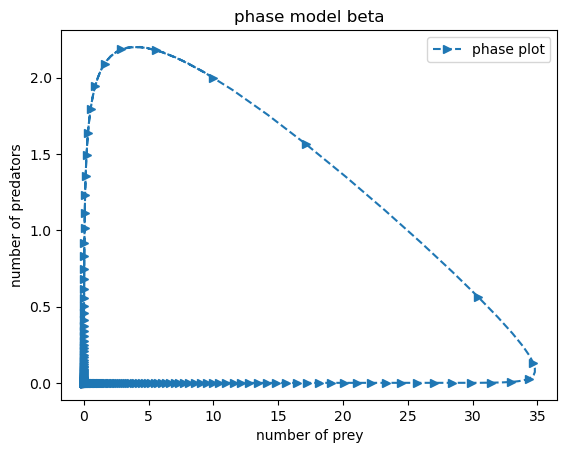

In [112]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("phase model beta")

Changing beta changes the rate at which prey is removed from the system/the interaction between prey and predators. This means that when beta increases, the prey are able to grow much more before encountering a decrease due to predation.

In [113]:
alpha = 1.
beta = 1.2
gamma = 40.
delta = 1.

In [114]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [115]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [116]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model gamma')

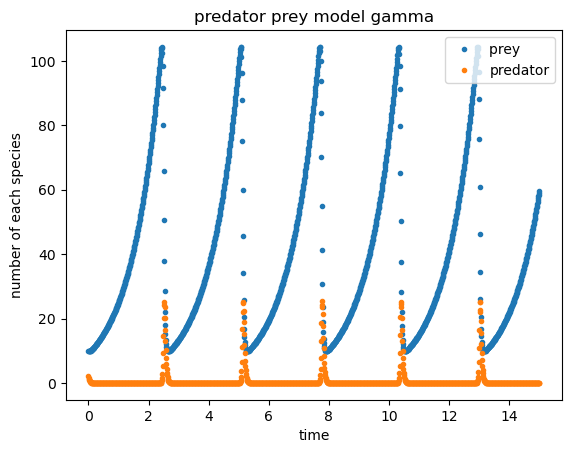

In [117]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model gamma")

Text(0.5, 1.0, 'phase model gamma')

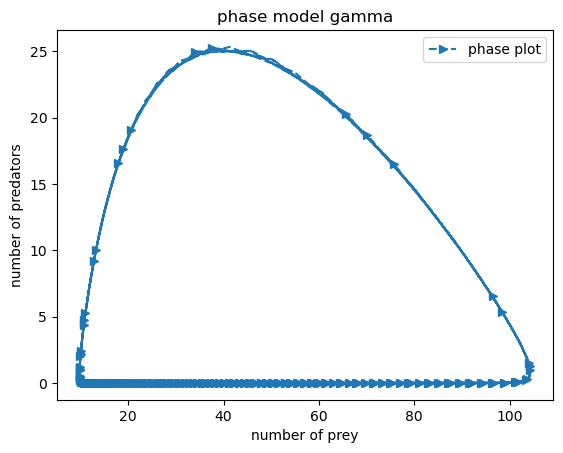

In [118]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("phase model gamma")

In [448]:
alpha = 1.
beta = 1.2
gamma = 15.
delta = 1.

In [449]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [450]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [451]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model gamma')

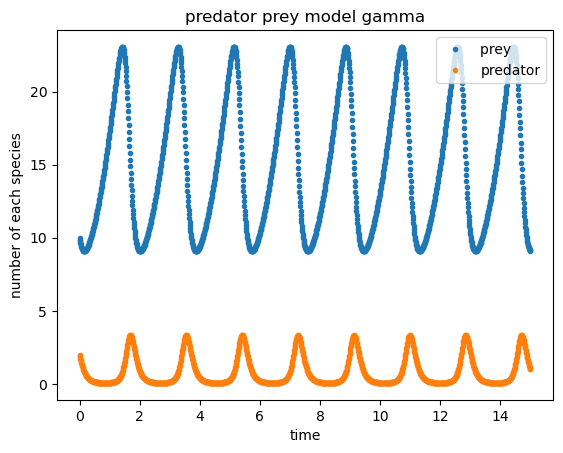

In [452]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model gamma")

Text(0.5, 1.0, 'phase model gamma')

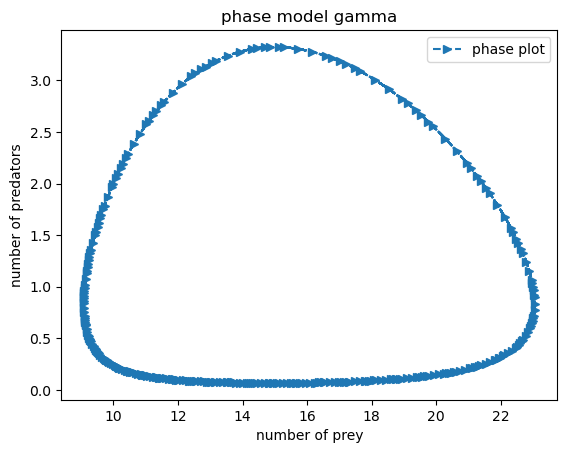

In [453]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("phase model gamma")

I know from the beginning of the lecture that gamma is supposed to affect the natural removal of predators from the population. However, increasing gamma causes the predator and prey populations to diverge and then come back together, but the phase plot gets more and more sporatic looking. I guess the death of so many predators at once causes the system to short-circuit? I don't know.

In [458]:
alpha = 1.
beta = 1.2
gamma = 4.
delta = 10.

In [459]:
x0 = 10
y0 = 2
u_RK4[0] = np.array([x0, y0])

In [460]:
for n in range(N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

In [461]:
time = np.linspace(0.0, T,N)
x_RK4 = u_RK4[:,0]
y_RK4 = u_RK4[:,1]

Text(0.5, 1.0, 'predator prey model delta')

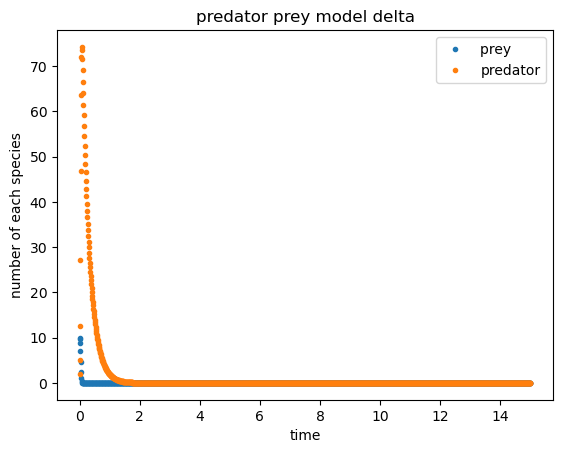

In [462]:
plt.plot(time, x_RK4, '.', label = 'prey ')
plt.plot(time, y_RK4, '.', label = 'predator')
plt.legend(loc='upper right')
#labels
plt.xlabel("time")
plt.ylabel("number of each species")
#title
plt.title("predator prey model delta")

Text(0.5, 1.0, 'phase model delta')

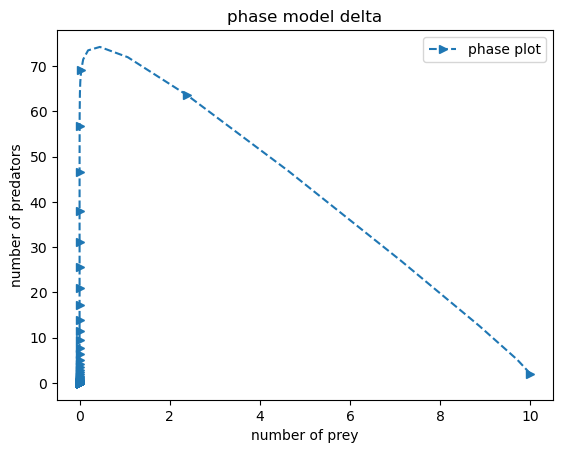

In [463]:
plt.plot(x_RK4, y_RK4, '-->', markevery=5, label = 'phase plot')
plt.legend(loc='upper right')
#labels
plt.xlabel("number of prey")
plt.ylabel("number of predators")
#title
plt.title("phase model delta")

Changing delta changes the growth rate of the predator population. In this example, since the predator population grows so fast, the system gets completely depleted.

#### E.5 (Advanced, required for grad students)
Modify the differential equations to include other types of interactions. See advanced predator prey example link at the top for ideas. You might add in a self-eating (i.e. $-ay^2$) term into the predator equation. Or do the zombie apocalypse example linked above.

Text(0.5, 1.0, 'zombie apocalypse model')

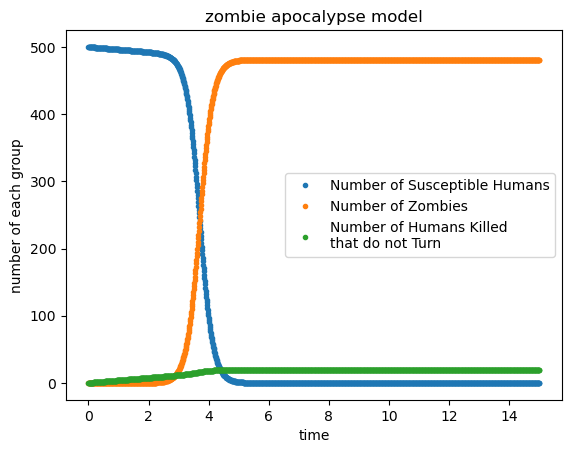

In [492]:

# I used the parameters on the zombie apocalypse example but changed the 
# birth and death rates to match global population data

P = 0.0161
d = 0.0077
B = 0.0095
G = 0.0001
A = 0.0001

def f(u):
    S = u[0]
    Z = u[1]
    R = u[2]
    return np.array([P - B*S*Z - d*S, B*S*Z + G*R - A*S*Z, d*S + A*S*Z])
    
T = 15
dt = 0.01
N = int(T/dt) + 1

S0 = 500.
Z0 = 0
R0 = 0

u_RK4 = np.zeros((N,3))

u_RK4[0] = np.array([S0, Z0, R0])

for n in range (N-1):
    u_RK4[n+1] = RK4(u_RK4[n], f, dt)

time = np.linspace(0.0, T,N)
S_RK4 = u_RK4[:,0]
Z_RK4 = u_RK4[:,1]
R_RK4 = u_RK4[:,2]

plt.plot(time, S_RK4, '.', label = 'Number of Susceptible Humans')
plt.plot(time, Z_RK4, '.', label = 'Number of Zombies')
plt.plot(time, R_RK4, '.', label = 'Number of Humans Killed' + '\n' + 'that do not Turn')
plt.legend(loc='center right')
#labels
plt.xlabel("time")
plt.ylabel("number of each group")
#title
plt.title("zombie apocalypse model")

Looks like most people just turn into zombies, whether while alive or once dead. Not many people die and stay dead